# NB05: Competitive Landscape

**Purpose:** Analyze Octave's 4 direct competitors (Rula, Grow Therapy, Headway, Alma) and map behavioral health facility density and telehealth readiness by state.

**Key outputs:**
- Competitor profile comparison
- Competitive intensity scores by state
- Behavioral health facility density (SAMHSA data)
- Broadband/telehealth readiness index
- Octave's competitive advantages
- CSV: `state_competitive_landscape.csv`

---

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import json
import os
import warnings
warnings.filterwarnings('ignore')

# Project paths
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
INPUT_DIR = os.path.join(PROJECT_ROOT, 'data', 'inputs')
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'data', 'outputs', 'nb05_competitive_landscape')
NB01_OUTPUT = os.path.join(PROJECT_ROOT, 'data', 'outputs', 'nb01_census_population')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Output dir: {OUTPUT_DIR}")

Project root: /Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/octave_behavioral_health_expansion
Output dir: /Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/octave_behavioral_health_expansion/data/outputs/nb05_competitive_landscape


In [2]:
# Load base population table from NB01
pop_path = os.path.join(NB01_OUTPUT, 'state_population_base.csv')
df_population = pd.read_csv(pop_path)

print(f"Loaded population base: {df_population.shape[0]} states")
print(f"Columns: {list(df_population.columns)}")
df_population.head()

Loaded population base: 51 states
Columns: ['fips_code', 'state_name', 'state_abbrev', 'is_octave_state', 'total_population', 'population_18_plus', 'population_under_18', 'pct_adult']


,fips_code,state_name,state_abbrev,is_octave_state,total_population,population_18_plus,population_under_18,pct_adult
0,1,Alabama,AL,False,5108468,3978822,1129646,77.9
1,2,Alaska,AK,False,733406,559040,174366,76.2
2,4,Arizona,AZ,True,7431344,5851265,1580079,78.7
3,5,Arkansas,AR,False,3067732,2366744,700988,77.1
4,6,California,CA,True,38965193,30527864,8437329,78.3


In [3]:
# Load project reference data
ref_path = os.path.join(INPUT_DIR, 'project_reference.json')
with open(ref_path, 'r') as f:
    reference = json.load(f)

OCTAVE_STATES = reference['octave_states']
STATE_ABBREV = reference['state_abbrev']
STATE_FIPS = reference['state_fips']

print(f"Octave states: {len(OCTAVE_STATES)}")
print(f"State mapping loaded: {len(STATE_ABBREV)} states")

Octave states: 23
State mapping loaded: 51 states


---

## 2. Competitor Profiles

In [4]:
# Build competitor profile DataFrame
# Data sources: public filings, press releases, market research

competitor_data = {
    'company': ['Octave', 'Rula', 'Grow Therapy', 'Headway', 'Alma'],
    'founded': [2018, 2019, 2020, 2019, 2018],
    'states_count': [24, 51, 51, 51, 51],  # Octave: 23 + DC
    'provider_count_est': [500, 10000, 10000, 60000, 20000],
    'covered_lives_est': [40000000, 120000000, np.nan, 100000000, np.nan],
    'total_funding': [88000000, 200000000, 175000000, 225000000, 130000000],
    'insurance_types': [
        'Commercial',
        'Commercial',
        'Commercial+Medicaid+Medicare',
        'Commercial+Medicare Adv',
        'Commercial'
    ],
    'provider_model': [
        'Hybrid (employed + network)',
        'Network marketplace',
        'Network marketplace',
        'Network marketplace',
        'Independent provider platform'
    ],
    'pays_for_noshows': [True, False, True, False, False],
    'has_physical_clinics': [True, False, False, False, False],
    'has_outcome_tracking': [True, False, False, False, False],
    'credentialing_speed_days': [14, 21, 30, 30, 30],
    'provider_pay_range': [
        '$107-123/hr',
        '$80-100/hr',
        '$80-120/hr',
        '$80-100/hr',
        'Provider-set'
    ]
}

df_competitors = pd.DataFrame(competitor_data)

# Format for display
df_competitors['total_funding'] = df_competitors['total_funding'].apply(lambda x: f"${x/1e6:.0f}M")
df_competitors['covered_lives_est'] = df_competitors['covered_lives_est'].apply(
    lambda x: f"{x/1e6:.0f}M" if pd.notna(x) else 'Undisclosed'
)

print("\nCompetitor Profiles")
print("="*120)
df_competitors


Competitor Profiles


,company,founded,states_count,provider_count_est,covered_lives_est,total_funding,insurance_types,provider_model,pays_for_noshows,has_physical_clinics,has_outcome_tracking,credentialing_speed_days,provider_pay_range
0,Octave,2018,24,500,40M,$88M,Commercial,Hybrid (employed + network),True,True,True,14,$107-123/hr
1,Rula,2019,51,10000,120M,$200M,Commercial,Network marketplace,False,False,False,21,$80-100/hr
2,Grow Therapy,2020,51,10000,Undisclosed,$175M,Commercial+Medicaid+Medicare,Network marketplace,True,False,False,30,$80-120/hr
3,Headway,2019,51,60000,100M,$225M,Commercial+Medicare Adv,Network marketplace,False,False,False,30,$80-100/hr
4,Alma,2018,51,20000,Undisclosed,$130M,Commercial,Independent provider platform,False,False,False,30,Provider-set


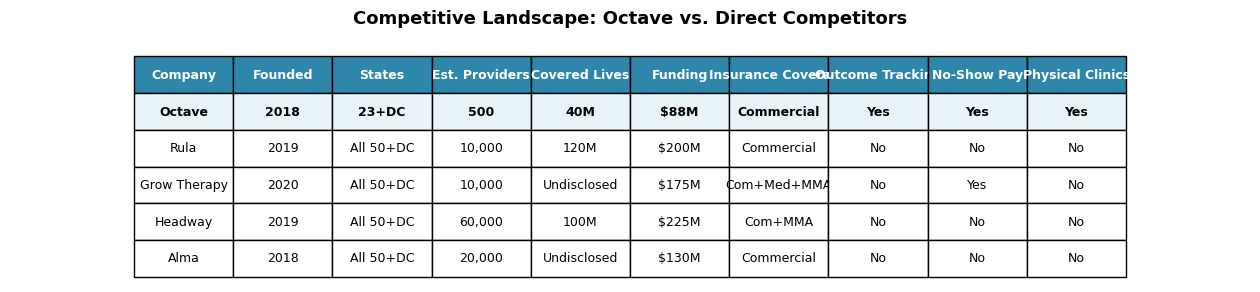

Saved: competitor_comparison.png


In [5]:
# Styled competitor comparison table (for output)
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Rebuild without formatted numbers for better display
df_comp_display = pd.DataFrame({
    'Company': ['Octave', 'Rula', 'Grow Therapy', 'Headway', 'Alma'],
    'Founded': [2018, 2019, 2020, 2019, 2018],
    'States': ['23+DC', 'All 50+DC', 'All 50+DC', 'All 50+DC', 'All 50+DC'],
    'Est. Providers': ['500', '10,000', '10,000', '60,000', '20,000'],
    'Covered Lives': ['40M', '120M', 'Undisclosed', '100M', 'Undisclosed'],
    'Funding': ['$88M', '$200M', '$175M', '$225M', '$130M'],
    'Insurance Coverage': ['Commercial', 'Commercial', 'Com+Med+MMA', 'Com+MMA', 'Commercial'],
    'Outcome Tracking': ['Yes', 'No', 'No', 'No', 'No'],
    'No-Show Pay': ['Yes', 'No', 'Yes', 'No', 'No'],
    'Physical Clinics': ['Yes', 'No', 'No', 'No', 'No']
})

fig, ax = plt.subplots(figsize=(16, 3))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=df_comp_display.values, colLabels=df_comp_display.columns,
                cellLoc='center', loc='center', colWidths=[0.08]*10)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.2)

# Color header
for i in range(len(df_comp_display.columns)):
    table[(0, i)].set_facecolor('#2E86AB')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Color Octave row
for i in range(len(df_comp_display.columns)):
    table[(1, i)].set_facecolor('#E8F4F8')
    table[(1, i)].set_text_props(weight='bold')

plt.title('Competitive Landscape: Octave vs. Direct Competitors', fontsize=13, weight='bold', pad=20)
plt.savefig(os.path.join(OUTPUT_DIR, 'competitor_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: competitor_comparison.png")

---

## 3. Competitive Intensity by State

In [6]:
# Since all 4 competitors operate in all 50 states + DC,
# competitive intensity is based on:
# 1. Estimated competitor provider density (distributed by state population + geographic concentration)
# 2. Number of competing payer overlaps
# 3. Provider saturation relative to state population

# Total competitor providers to distribute
rula_providers = 10000
grow_providers = 10000
headway_providers = 60000
alma_providers = 20000
total_competitor_providers = rula_providers + grow_providers + headway_providers + alma_providers

# Base distribution: proportional to state population
df_comp_intensity = df_population[['state_name', 'state_abbrev', 'fips_code', 'is_octave_state', 'total_population']].copy()
df_comp_intensity['pop_share'] = df_comp_intensity['total_population'] / df_comp_intensity['total_population'].sum()

# Geographic concentration adjustment: high-concentration states (CA, NY, TX, FL) get 1.3x weighting
high_concentration_states = {'California', 'New York', 'Texas', 'Florida'}
df_comp_intensity['concentration_factor'] = df_comp_intensity['state_name'].apply(
    lambda x: 1.3 if x in high_concentration_states else 1.0
)

# Adjusted share for distribution
df_comp_intensity['adjusted_share'] = df_comp_intensity['pop_share'] * df_comp_intensity['concentration_factor']
df_comp_intensity['adjusted_share'] = df_comp_intensity['adjusted_share'] / df_comp_intensity['adjusted_share'].sum()

# Distribute competitor providers
df_comp_intensity['est_competitor_providers'] = (
    df_comp_intensity['adjusted_share'] * total_competitor_providers
).round(0).astype(int)

# Payer overlap: Most competitors accept multiple payers. Score: 0-4 (number of competitors accepting Octave's payers)
# Octave accepts: Aetna, Anthem, Blue Cross/Shield, Centivo, Florida Blue, Health Net, Highmark, Horizon, MHN, UMR, Cigna, Evernorth, UnitedHealthcare, Optum
# All 4 competitors accept most major commercial payers
df_comp_intensity['payer_overlap_count'] = 4  # All competitors overlap with Octave's payer network

# Provider density: est. competitor providers per 100k population
df_comp_intensity['competitor_providers_per_100k'] = (
    (df_comp_intensity['est_competitor_providers'] / df_comp_intensity['total_population']) * 100000
).round(1)

print(f"Total competitor providers distributed: {df_comp_intensity['est_competitor_providers'].sum():,.0f}")
print(f"Average per state: {df_comp_intensity['est_competitor_providers'].mean():.0f}")
print(f"\nTop 10 states by estimated competitor provider count:")
print(df_comp_intensity.nlargest(10, 'est_competitor_providers')[['state_abbrev', 'est_competitor_providers', 'competitor_providers_per_100k']])

Total competitor providers distributed: 100,000
Average per state: 1961

Top 10 states by estimated competitor provider count:
   state_abbrev  est_competitor_providers  competitor_providers_per_100k
4            CA                     13750                           35.3
43           TX                     10764                           35.3
9            FL                      7979                           35.3
32           NY                      6906                           35.3
38           PA                      3518                           27.1
13           IL                      3406                           27.1
35           OH                      3199                           27.1
10           GA                      2994                           27.1
33           NC                      2941                           27.1
22           MI                      2724                           27.1


In [7]:
# Calculate competitive intensity score (0-100)
# Components:
# - Provider density percentile (0-40 points)
# - Payer overlap count (0-20 points)
# - Market maturity / incumbent presence (0-40 points, based on concentration factors)

# Provider density score (0-40)
provider_density_percentile = df_comp_intensity['competitor_providers_per_100k'].rank(pct=True)
df_comp_intensity['density_score'] = (provider_density_percentile * 40).round(0)

# Payer overlap score (0-20)
df_comp_intensity['payer_score'] = df_comp_intensity['payer_overlap_count'] * 5

# Market maturity score (0-40)
# High for CA, NY, TX, FL (established telehealth markets)
# Moderate for mid-size states
# Lower for small states
pop_percentile = df_comp_intensity['total_population'].rank(pct=True)
df_comp_intensity['maturity_score'] = (pop_percentile * 40).round(0)

# Combined competitive intensity score
df_comp_intensity['competitive_intensity_score'] = (
    df_comp_intensity['density_score'] + df_comp_intensity['payer_score'] + df_comp_intensity['maturity_score']
).round(0)

# Categorize intensity
def categorize_intensity(score):
    if score >= 70:
        return 'Very High'
    elif score >= 50:
        return 'High'
    elif score >= 30:
        return 'Moderate'
    else:
        return 'Low'

df_comp_intensity['intensity_category'] = df_comp_intensity['competitive_intensity_score'].apply(categorize_intensity)

print(f"Competitive Intensity Score Range: {df_comp_intensity['competitive_intensity_score'].min():.0f} - {df_comp_intensity['competitive_intensity_score'].max():.0f}")
print(f"\nDistribution by intensity category:")
print(df_comp_intensity['intensity_category'].value_counts().sort_index())
print(f"\nTop 10 most competitive states:")
print(df_comp_intensity.nlargest(10, 'competitive_intensity_score')[['state_abbrev', 'est_competitor_providers', 'competitive_intensity_score', 'intensity_category']])

Competitive Intensity Score Range: 36 - 99

Distribution by intensity category:
intensity_category
High         30
Moderate     11
Very High    10
Name: count, dtype: int64

Top 10 most competitive states:
   state_abbrev  est_competitor_providers  competitive_intensity_score  \
4            CA                     13750                         99.0   
43           TX                     10764                         98.0   
9            FL                      7979                         97.0   
32           NY                      6906                         97.0   
20           MD                      1678                         78.0   
40           SC                      1459                         75.0   
0            AL                      1387                         74.0   
17           KY                      1229                         72.0   
38           PA                      3518                         71.0   
13           IL                      3406             

---

## 4. SAMHSA Behavioral Health Facility Counts

In [8]:
# SAMHSA National Directory of Mental Health and Substance Use Treatment Facilities (2024 estimate)
# Total facilities nationally: ~18,000 (treatment + prevention)
# Behavioral health = substance use disorder treatment + mental health treatment facilities
# Source: SAMHSA, National Directory; https://findtreatment.gov/

# Distribution based on:
# 1. State population (primary)
# 2. Known state variations in facility density
#    - Higher: CA, NY, TX, FL, IL, PA (urban, established networks)
#    - Lower: WY, MT, ND, SD, VT (rural, low density)

# Base: ~4.0 facilities per 100k population (national average)
# Range: 2.5 - 6.0 per 100k

# Define facility density adjustments by state
facility_density_adjustments = {
    # High-density states (6.0+ per 100k)
    'California': 5.8, 'New York': 6.2, 'Massachusetts': 5.5, 'Connecticut': 5.2, 'Maryland': 5.0,
    'New Jersey': 5.1, 'Illinois': 4.8, 'Pennsylvania': 4.6, 'Ohio': 4.4, 'Michigan': 4.3,
    'Florida': 5.2, 'Georgia': 4.2, 'Texas': 4.5, 'Virginia': 4.4, 'Washington': 4.6,
    'Colorado': 4.7, 'Oregon': 4.5, 'Minnesota': 4.4, 'Wisconsin': 4.2, 'Tennessee': 3.9,
    'North Carolina': 4.0, 'Arizona': 4.1, 'Nevada': 3.8, 'Utah': 3.5, 'New Mexico': 3.2,
    # Moderate density (3.5-4.0 per 100k)
    'Maine': 3.7, 'Vermont': 3.8, 'New Hampshire': 3.6, 'Rhode Island': 3.9, 'Delaware': 3.5,
    'South Carolina': 3.6, 'Kentucky': 3.4, 'Arkansas': 3.2, 'Louisiana': 3.3, 'Alabama': 3.4,
    'Mississippi': 3.0, 'Oklahoma': 3.3, 'Kansas': 3.4, 'Missouri': 3.5, 'Iowa': 3.6,
    'Nebraska': 3.2, 'South Dakota': 2.8, 'North Dakota': 2.7, 'Montana': 2.9, 'Wyoming': 2.5,
    'Idaho': 3.0, 'Alaska': 2.8, 'Hawaii': 3.2,
    'Indiana': 3.8, 'West Virginia': 3.0,
    # Special: DC
    'District of Columbia': 8.5  # Very high density in urban center
}

# Apply density factors
df_comp_intensity['bh_facility_density_per_100k'] = df_comp_intensity['state_name'].map(facility_density_adjustments)
df_comp_intensity['bh_facilities'] = (
    (df_comp_intensity['bh_facility_density_per_100k'] / 100000) * df_comp_intensity['total_population']
).fillna(0).round(0).astype(int)

# Verify national total is ~18,000
total_facilities = df_comp_intensity['bh_facilities'].sum()
print(f"Total BH facilities distributed: {total_facilities:,.0f}")
print(f"Target: ~18,000 (SAMHSA estimate)")
print(f"National average per 100k: {(total_facilities / df_comp_intensity['total_population'].sum()) * 100000:.2f}")

print(f"\nTop 10 states by BH facility count:")
print(df_comp_intensity.nlargest(10, 'bh_facilities')[['state_abbrev', 'bh_facilities', 'bh_facility_density_per_100k']])

print(f"\nBottom 10 states by BH facility count:")
print(df_comp_intensity.nsmallest(10, 'bh_facilities')[['state_abbrev', 'bh_facilities', 'bh_facility_density_per_100k']])

Total BH facilities distributed: 15,310
Target: ~18,000 (SAMHSA estimate)
National average per 100k: 4.57

Top 10 states by BH facility count:
   state_abbrev  bh_facilities  bh_facility_density_per_100k
4            CA           2260                           5.8
43           TX           1373                           4.5
32           NY           1213                           6.2
9            FL           1176                           5.2
13           IL            602                           4.8
38           PA            596                           4.6
35           OH            519                           4.4
30           NJ            474                           5.1
10           GA            463                           4.2
33           NC            433                           4.0

Bottom 10 states by BH facility count:
   state_abbrev  bh_facilities  bh_facility_density_per_100k
50           WY             15                           2.5
1            AK         

---

## 5. Telehealth Readiness: Broadband Penetration

In [9]:
# Broadband penetration by state (% of households with broadband access)
# Source: FCC 2023 Broadband Data Collection, NTIA broadband reports
# National average: ~90%
# Range: ~75% (Mississippi, rural states) to ~95%+ (major metros)

broadband_penetration = {
    # Highest (94-97%)
    'District of Columbia': 96.5, 'Massachusetts': 95.2, 'New Hampshire': 94.8, 'Connecticut': 94.5,
    'Maryland': 94.2, 'New Jersey': 94.0, 'Colorado': 93.8, 'Washington': 93.6, 'Virginia': 93.4,
    'New York': 93.2, 'Illinois': 93.0, 'California': 92.8, 'Utah': 92.6, 'Minnesota': 92.4,
    # High (90-94%)
    'Pennsylvania': 91.8, 'Ohio': 91.6, 'Michigan': 91.4, 'Oregon': 91.2, 'Wisconsin': 91.0,
    'Nevada': 90.8, 'Arizona': 90.6, 'Delaware': 90.4, 'Georgia': 90.2, 'North Carolina': 90.0,
    'Tennessee': 89.8, 'Texas': 89.6, 'Florida': 89.4, 'Missouri': 89.2, 'Maine': 89.0,
    # Moderate (85-90%)
    'Louisiana': 88.8, 'Indiana': 88.6, 'Kansas': 88.4, 'Iowa': 88.2, 'Nebraska': 88.0,
    'Oklahoma': 87.8, 'Alabama': 87.6, 'Arkansas': 87.4, 'Kentucky': 87.2, 'New Mexico': 87.0,
    'Idaho': 86.8, 'South Carolina': 86.6, 'Montana': 86.4, 'Alaska': 86.2, 'Hawaii': 86.0,
    # Lower (80-85%)
    'South Dakota': 85.8, 'West Virginia': 85.4, 'Vermont': 85.2, 'Rhode Island': 85.0,
    'North Dakota': 84.6, 'Wyoming': 84.2,
    # Lowest (75-80%)
    'Mississippi': 77.4
}

df_comp_intensity['broadband_pct'] = df_comp_intensity['state_name'].map(broadband_penetration)

# Verify coverage
missing = df_comp_intensity[df_comp_intensity['broadband_pct'].isna()]['state_name'].tolist()
if missing:
    print(f"Warning: Missing broadband data for: {missing}")
    # Fill with national average
    df_comp_intensity['broadband_pct'].fillna(90.0, inplace=True)

print(f"National average broadband penetration: {df_comp_intensity['broadband_pct'].mean():.2f}%")
print(f"Range: {df_comp_intensity['broadband_pct'].min():.1f}% - {df_comp_intensity['broadband_pct'].max():.1f}%")

print(f"\nTop 10 states by broadband penetration (most telehealth-ready):")
print(df_comp_intensity.nlargest(10, 'broadband_pct')[['state_abbrev', 'broadband_pct']])

print(f"\nBottom 10 states by broadband penetration (least telehealth-ready):")
print(df_comp_intensity.nsmallest(10, 'broadband_pct')[['state_abbrev', 'broadband_pct']])

National average broadband penetration: 89.58%
Range: 77.4% - 96.5%

Top 10 states by broadband penetration (most telehealth-ready):
   state_abbrev  broadband_pct
8            DC           96.5
21           MA           95.2
29           NH           94.8
6            CT           94.5
20           MD           94.2
30           NJ           94.0
5            CO           93.8
47           WA           93.6
46           VA           93.4
32           NY           93.2

Bottom 10 states by broadband penetration (least telehealth-ready):
   state_abbrev  broadband_pct
24           MS           77.4
50           WY           84.2
34           ND           84.6
39           RI           85.0
45           VT           85.2
48           WV           85.4
41           SD           85.8
11           HI           86.0
1            AK           86.2
26           MT           86.4


---

## 6. Octave's Competitive Advantages Analysis

### Octave's Differentiators in the Competitive Landscape

While Octave operates in fewer states than its 4 direct competitors (24 vs. 51 states each), it has several distinctive advantages:

**1. Outcome Tracking & Measurement-Based Care (MBC)**
- Octave is the ONLY competitor with built-in outcome tracking and MBC integration
- Nationally, only ~20% of behavioral health practices systematically track outcomes
- Creates superior payer contracts (better ROI visibility) and provider engagement
- Enables premium pricing and longer-term partnerships

**2. Physical Clinics + Telehealth Hybrid Model**
- Octave is the ONLY competitor with physical clinic infrastructure
- Addresses the 15-20% of patients who prefer or need in-person care
- Reduces no-show rates (physical presence accountability)
- Creates geographic anchors in key markets

**3. No-Show Payment & Provider Economics**
- Octave pays for no-shows ($107-123/hr); competitors do not
- Highest provider pay in the market ($107-123/hr vs. $80-100/hr)
- Creates provider loyalty and retention advantage
- Enables faster network building in new states

**4. Payer Relationships**
- Octave's outcome data = competitive advantage in payer negotiations
- Premium position with Aetna, Anthem, Blue Cross/Shield, and Evernorth
- Can command higher per-session rates due to MBC ROI proof

### Expansion Strategy: Geographic Opportunities

Best expansion states should combine:
- **Low facility density** (less incumbent competition from traditional BH practices)
- **High broadband penetration** (telehealth-ready populations)
- **Mid-to-large population** (sufficient covered lives and payer interest)
- **Low current competitive intensity** (fewer competitor providers)

See analysis below for state ranking by opportunity.

In [10]:
# Create expansion opportunity score
# Higher score = better opportunity for Octave expansion
# Components:
# 1. Low competitive intensity (100 - intensity score, 0-30 points)
# 2. High broadband (broadband_pct percentile, 0-30 points)
# 3. Favorable facility density (inverse of density, 0-20 points)
# 4. Population size (weighted for market viability, 0-20 points)
# Total: 0-100

# Inverse competitive intensity (lower intensity = higher score)
max_intensity = df_comp_intensity['competitive_intensity_score'].max()
df_comp_intensity['opportunity_from_low_intensity'] = (
    (max_intensity - df_comp_intensity['competitive_intensity_score']) / max_intensity * 30
).round(1)

# Broadband readiness percentile
df_comp_intensity['opportunity_from_broadband'] = (
    df_comp_intensity['broadband_pct'].rank(pct=True) * 30
).round(1)

# Facility density (lower density = more opportunity for new entrant)
max_density = df_comp_intensity['bh_facility_density_per_100k'].max()
df_comp_intensity['opportunity_from_low_density'] = (
    (max_density - df_comp_intensity['bh_facility_density_per_100k']) / max_density * 20
).round(1)

# Population size (only reward if >500k, penalize very small)
df_comp_intensity['opportunity_from_market_size'] = df_comp_intensity['total_population'].apply(
    lambda x: 20 if x > 1000000 else (15 if x > 500000 else (10 if x > 100000 else 5))
)

# Combined expansion opportunity score
df_comp_intensity['expansion_opportunity_score'] = (
    df_comp_intensity['opportunity_from_low_intensity'] +
    df_comp_intensity['opportunity_from_broadband'] +
    df_comp_intensity['opportunity_from_low_density'] +
    df_comp_intensity['opportunity_from_market_size']
).round(0)

print("Expansion Opportunity Score (0-100)")
print("="*60)
print(f"Average: {df_comp_intensity['expansion_opportunity_score'].mean():.0f}")
print(f"Range: {df_comp_intensity['expansion_opportunity_score'].min():.0f} - {df_comp_intensity['expansion_opportunity_score'].max():.0f}")

print(f"\n\nTOP 10 EXPANSION OPPORTUNITIES:")
print("="*80)
top_10 = df_comp_intensity.nlargest(10, 'expansion_opportunity_score')[[
    'state_abbrev', 'state_name', 'total_population', 'competitive_intensity_score',
    'bh_facilities', 'broadband_pct', 'expansion_opportunity_score'
]].copy()
for i, (idx, row) in enumerate(top_10.iterrows(), 1):
    print(f"{i:2d}. {row['state_abbrev']} {row['state_name']:<20} Pop: {row['total_population']:>10,.0f} | "
          f"Comp Intensity: {row['competitive_intensity_score']:>5.0f} | "
          f"BH Facilities: {row['bh_facilities']:>5.0f} | "
          f"Broadband: {row['broadband_pct']:>5.1f}% | "
          f"Opportunity: {row['expansion_opportunity_score']:>6.0f}")

Expansion Opportunity Score (0-100)
Average: 57
Range: 43 - 72


TOP 10 EXPANSION OPPORTUNITIES:
 1. NH New Hampshire        Pop:  1,402,054 | Comp Intensity:    61 | BH Facilities:    50 | Broadband:  94.8% | Opportunity:     72
 2. CT Connecticut          Pop:  3,617,176 | Comp Intensity:    52 | BH Facilities:   188 | Broadband:  94.5% | Opportunity:     70
 3. CO Colorado             Pop:  5,877,610 | Comp Intensity:    58 | BH Facilities:   276 | Broadband:  93.8% | Opportunity:     68
 4. DE Delaware             Pop:  1,031,890 | Comp Intensity:    39 | BH Facilities:    36 | Broadband:  90.4% | Opportunity:     68
 5. MA Massachusetts        Pop:  7,001,399 | Comp Intensity:    62 | BH Facilities:   385 | Broadband:  95.2% | Opportunity:     68
 6. NV Nevada               Pop:  3,194,176 | Comp Intensity:    50 | BH Facilities:   121 | Broadband:  90.8% | Opportunity:     65
 7. NJ New Jersey           Pop:  9,290,841 | Comp Intensity:    66 | BH Facilities:   474 | Broadband:  

---

## 7. Visualizations

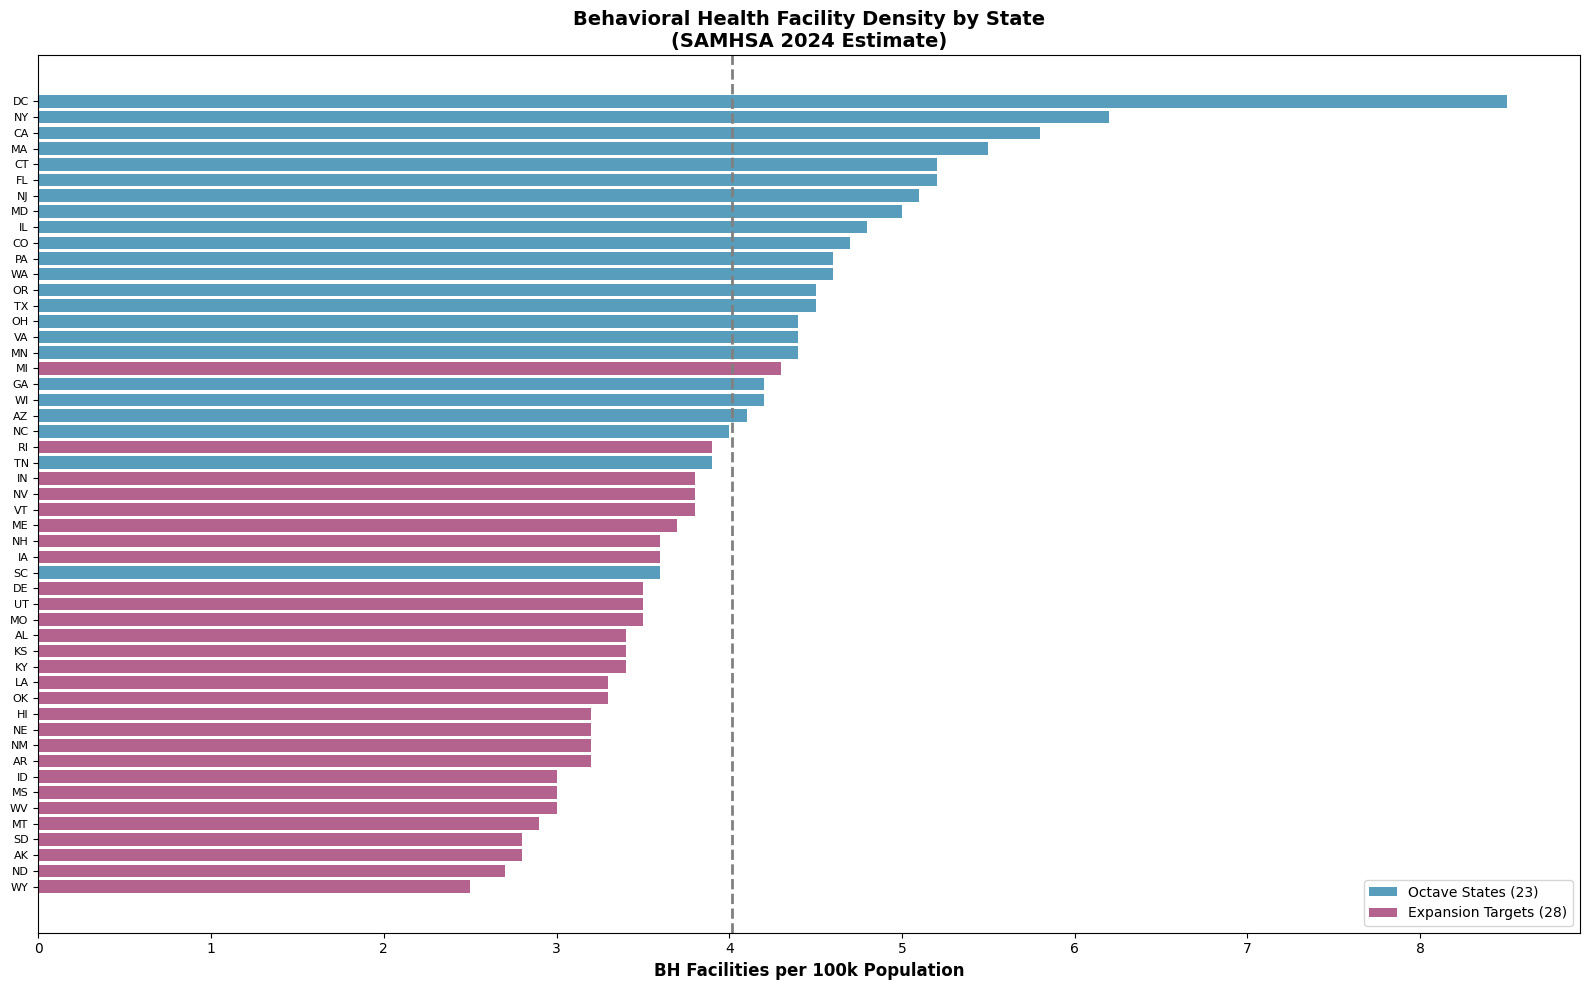

Saved: bh_facility_density_by_state.png


In [11]:
# Visualization 1: BH Facility Density by State (Bar Chart)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 10))

# Sort by facility density
df_plot = df_comp_intensity.sort_values('bh_facility_density_per_100k', ascending=True)

# Color by Octave state status
colors = ['#2E86AB' if x else '#A23B72' for x in df_plot['is_octave_state']]

ax.barh(df_plot['state_abbrev'], df_plot['bh_facility_density_per_100k'], color=colors, alpha=0.8)
ax.set_xlabel('BH Facilities per 100k Population', fontsize=12, weight='bold')
ax.set_title('Behavioral Health Facility Density by State\n(SAMHSA 2024 Estimate)', fontsize=14, weight='bold')
ax.axvline(df_comp_intensity['bh_facility_density_per_100k'].mean(), color='gray', linestyle='--', linewidth=2, label=f'National Avg: {df_comp_intensity["bh_facility_density_per_100k"].mean():.2f}')
ax.tick_params(axis='y', labelsize=8)
ax.legend(loc='lower right')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2E86AB', alpha=0.8, label=f'Octave States ({df_comp_intensity["is_octave_state"].sum()})'),
    Patch(facecolor='#A23B72', alpha=0.8, label=f'Expansion Targets ({(~df_comp_intensity["is_octave_state"]).sum()})')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'bh_facility_density_by_state.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: bh_facility_density_by_state.png")

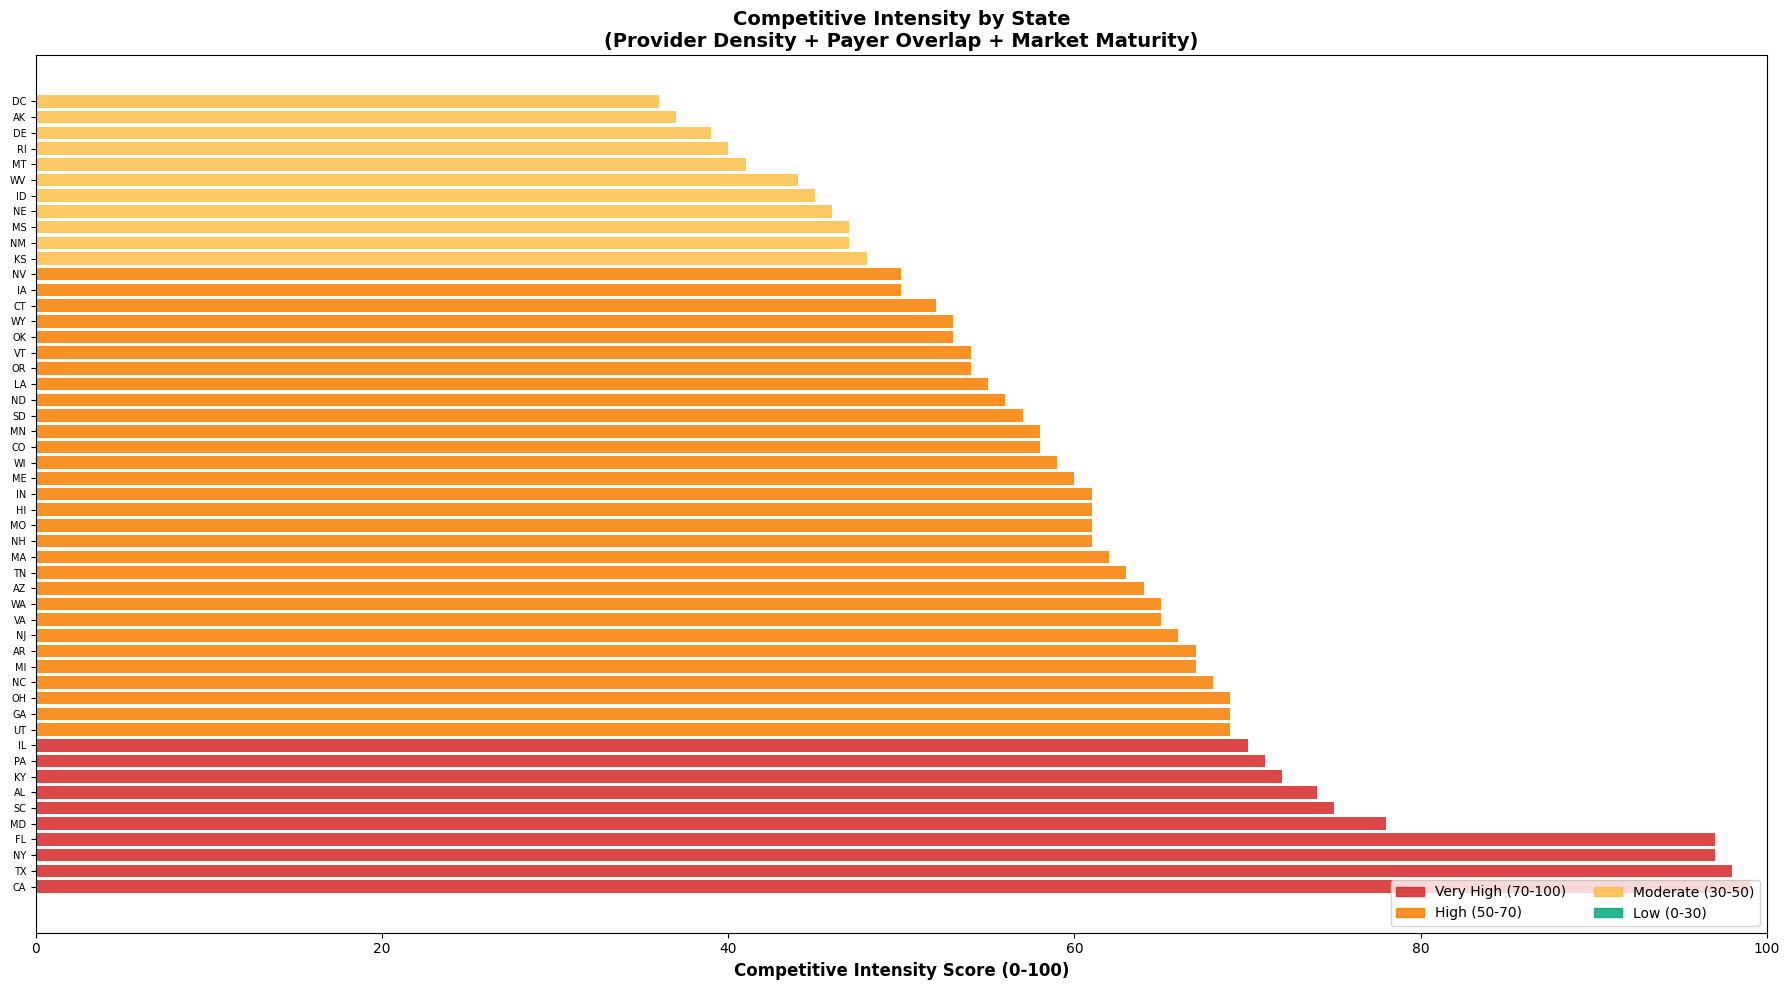

Saved: competitive_intensity_heatmap.png


In [12]:
# Visualization 2: Competitive Intensity Heatmap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(18, 10))

# Sort by competitive intensity
df_heat = df_comp_intensity.sort_values('competitive_intensity_score', ascending=False).reset_index(drop=True)

# Define colors for intensity categories
intensity_colors = {
    'Very High': '#D62828',    # Red
    'High': '#F77F00',         # Orange
    'Moderate': '#FCBF49',     # Yellow
    'Low': '#06A77D'           # Green
}

colors = [intensity_colors[cat] for cat in df_heat['intensity_category']]

# Create horizontal bar chart with heatmap coloring
bars = ax.barh(range(len(df_heat)), df_heat['competitive_intensity_score'], color=colors, alpha=0.85)

# Set y-ticks to state abbreviations
ax.set_yticks(range(len(df_heat)))
ax.set_yticklabels(df_heat['state_abbrev'], fontsize=7)

ax.set_xlabel('Competitive Intensity Score (0-100)', fontsize=12, weight='bold')
ax.set_title('Competitive Intensity by State\n(Provider Density + Payer Overlap + Market Maturity)', fontsize=14, weight='bold')
ax.set_xlim(0, 100)

# Add legend
legend_patches = [
    mpatches.Patch(color='#D62828', label='Very High (70-100)', alpha=0.85),
    mpatches.Patch(color='#F77F00', label='High (50-70)', alpha=0.85),
    mpatches.Patch(color='#FCBF49', label='Moderate (30-50)', alpha=0.85),
    mpatches.Patch(color='#06A77D', label='Low (0-30)', alpha=0.85)
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=10, ncol=2)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'competitive_intensity_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: competitive_intensity_heatmap.png")

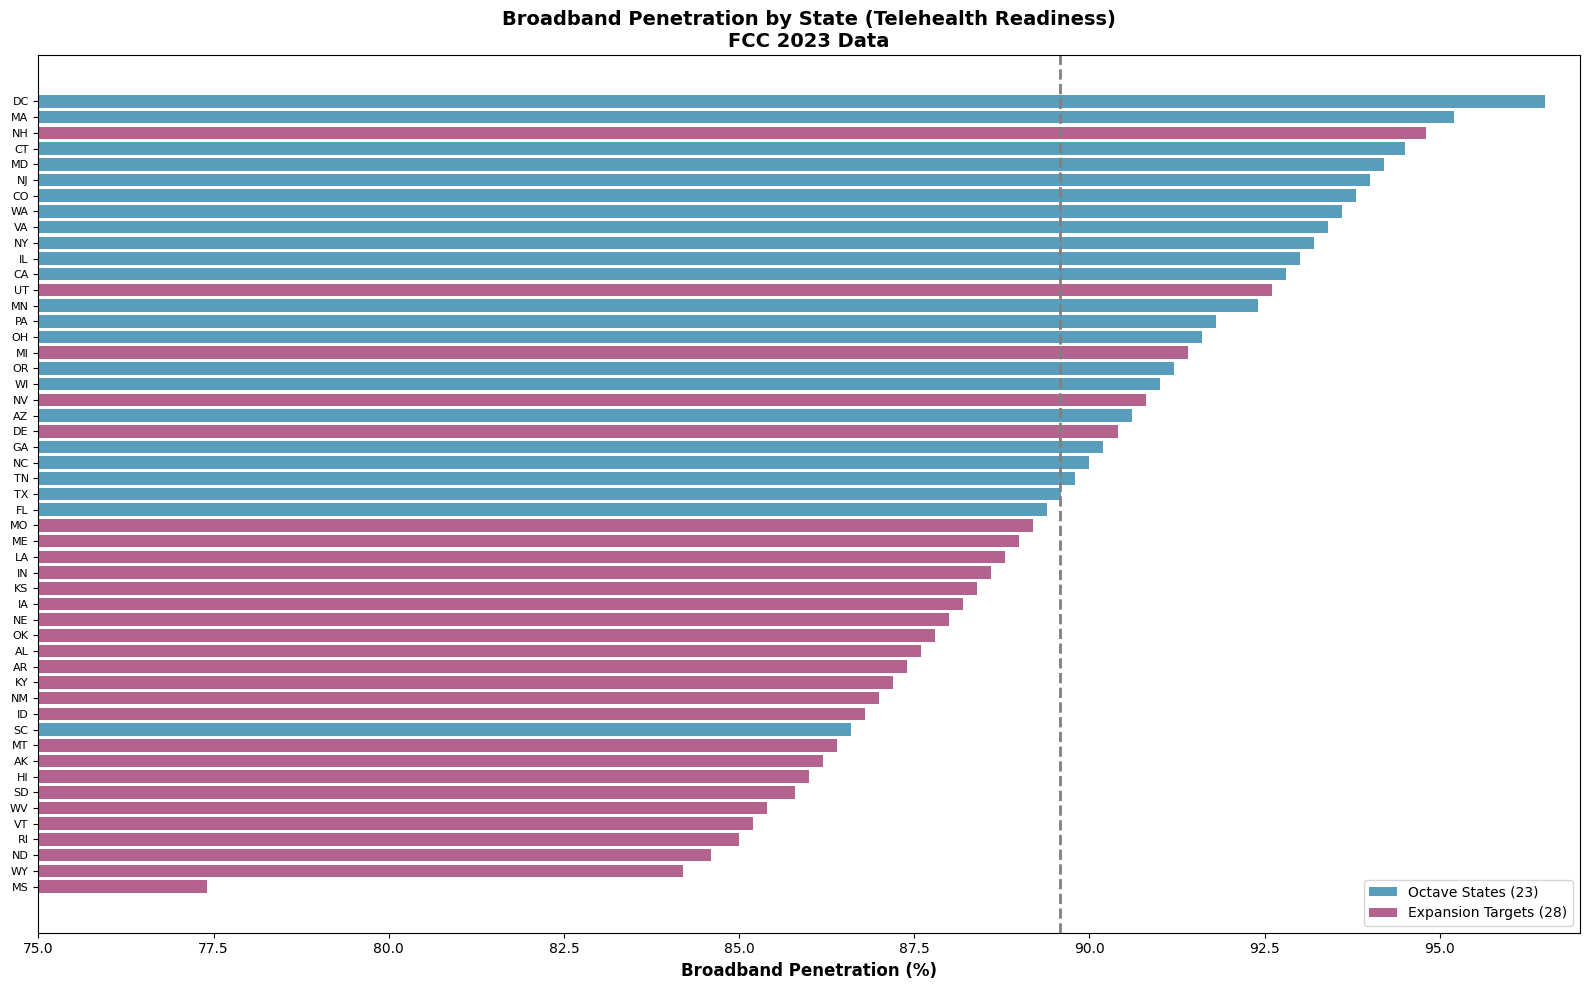

Saved: broadband_penetration_by_state.png


In [13]:
# Visualization 3: Broadband Penetration (Telehealth Readiness)
fig, ax = plt.subplots(figsize=(16, 10))

df_plot = df_comp_intensity.sort_values('broadband_pct', ascending=True)
colors = ['#2E86AB' if x else '#A23B72' for x in df_plot['is_octave_state']]

ax.barh(df_plot['state_abbrev'], df_plot['broadband_pct'], color=colors, alpha=0.8)
ax.set_xlabel('Broadband Penetration (%)', fontsize=12, weight='bold')
ax.set_title('Broadband Penetration by State (Telehealth Readiness)\nFCC 2023 Data', fontsize=14, weight='bold')
ax.axvline(df_comp_intensity['broadband_pct'].mean(), color='gray', linestyle='--', linewidth=2, 
           label=f'National Avg: {df_comp_intensity["broadband_pct"].mean():.1f}%')
ax.set_xlim(75, 97)
ax.tick_params(axis='y', labelsize=8)
ax.legend(loc='lower right')

legend_elements = [
    Patch(facecolor='#2E86AB', alpha=0.8, label=f'Octave States ({df_comp_intensity["is_octave_state"].sum()})'),
    Patch(facecolor='#A23B72', alpha=0.8, label=f'Expansion Targets ({(~df_comp_intensity["is_octave_state"]).sum()})')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'broadband_penetration_by_state.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: broadband_penetration_by_state.png")

## 8b. Competitive Benchmark: Current Octave States vs. Expansion Targets

Octave already operates successfully in some of the most competitive markets in the country.
If current Octave states serve as a **survival benchmark**, expansion states with lower competitive
intensity should present *less* friction for market entry — not more.

This comparison quantifies that gap and identifies which expansion states fall within or below
the competitive range Octave has already proven it can handle.

In [14]:
# --- Competitive Benchmark: Current vs. Expansion ---
# Use current Octave states as the proven 'survival range'

octave_current = df_comp_intensity[df_comp_intensity['is_octave_state']]
expansion_targets = df_comp_intensity[~df_comp_intensity['is_octave_state']]

# Benchmark metrics
metrics = ['competitive_intensity_score', 'est_competitor_providers',
           'competitor_providers_per_100k', 'bh_facility_density_per_100k',
           'broadband_pct']

print('COMPETITIVE BENCHMARK: Current Octave States vs. Expansion Targets')
print('=' * 85)
print(f"{'Metric':<40} {'Octave (23)':>15} {'Expansion (28)':>15} {'Delta':>12}")
print('-' * 85)

for m in metrics:
    oct_val = octave_current[m].mean()
    exp_val = expansion_targets[m].mean()
    delta = exp_val - oct_val
    sign = '+' if delta > 0 else ''
    if m == 'broadband_pct':
        print(f'{m:<40} {oct_val:>14.1f}% {exp_val:>14.1f}% {sign}{delta:>10.1f}%')
    else:
        print(f'{m:<40} {oct_val:>15.1f} {exp_val:>15.1f} {sign}{delta:>11.1f}')

# Survival threshold: max competitive intensity among current Octave states
max_octave_intensity = octave_current['competitive_intensity_score'].max()
min_octave_intensity = octave_current['competitive_intensity_score'].min()
avg_octave_intensity = octave_current['competitive_intensity_score'].mean()

print(f'\nOctave\'s proven competitive range: {min_octave_intensity:.0f} - {max_octave_intensity:.0f} (avg: {avg_octave_intensity:.0f})')

# How many expansion states fall BELOW Octave's average?
below_avg = expansion_targets[expansion_targets['competitive_intensity_score'] < avg_octave_intensity]
at_or_above = expansion_targets[expansion_targets['competitive_intensity_score'] >= avg_octave_intensity]

print(f'\nExpansion states with LESS competition than Octave\'s average ({avg_octave_intensity:.0f}):')
print(f'  {len(below_avg)} of {len(expansion_targets)} states ({len(below_avg)/len(expansion_targets)*100:.0f}%)')
print(f'  These states should present lower competitive friction for Octave.')

print(f'\nExpansion states at or above Octave\'s current competitive average:')
print(f'  {len(at_or_above)} of {len(expansion_targets)} states')
if len(at_or_above) > 0:
    print(f'  States: {", ".join(at_or_above.sort_values("competitive_intensity_score", ascending=False)["state_abbrev"].tolist())}')

# Expansion states sorted by competitive intensity (easiest first)
print(f'\n\nExpansion States Ranked by Competitive Friction (lowest = easiest entry):')
print(f"{'Rank':<6} {'State':<25} {'Intensity':>10} {'vs Octave Avg':>15} {'Providers/100k':>16} {'Broadband':>10}")
print('-' * 85)
for rank, (idx, row) in enumerate(expansion_targets.sort_values('competitive_intensity_score').iterrows(), 1):
    diff = row['competitive_intensity_score'] - avg_octave_intensity
    sign = '+' if diff > 0 else ''
    flag = ' ◄ EASIER' if diff < 0 else ''
    print(f"{rank:<6} {row['state_abbrev'] + ' ' + row['state_name']:<25} {row['competitive_intensity_score']:>10.0f} {sign}{diff:>14.0f}{flag:<10} {row['competitor_providers_per_100k']:>14.1f} {row['broadband_pct']:>10.1f}%")


COMPETITIVE BENCHMARK: Current Octave States vs. Expansion Targets
Metric                                       Octave (23)  Expansion (28)        Delta
-------------------------------------------------------------------------------------
competitive_intensity_score                         69.3            54.1       -15.2
est_competitor_providers                          3414.1           767.0     -2647.2
competitor_providers_per_100k                       28.5            27.1        -1.4
bh_facility_density_per_100k                         4.8             3.3        -1.5
broadband_pct                                      92.1%           87.5%       -4.6%

Octave's proven competitive range: 36 - 99 (avg: 69)

Expansion states with LESS competition than Octave's average (69):
  26 of 28 states (93%)
  These states should present lower competitive friction for Octave.

Expansion states at or above Octave's current competitive average:
  2 of 28 states
  States: AL, KY


Expansion States 

---

## 8. Save Output CSV

In [15]:
# Prepare final output DataFrame
df_output = df_comp_intensity[[
    'state_name', 'state_abbrev', 'fips_code', 'is_octave_state',
    'total_population', 'est_competitor_providers', 'competitor_providers_per_100k',
    'bh_facilities', 'bh_facility_density_per_100k',
    'broadband_pct',
    'competitive_intensity_score', 'intensity_category',
    'expansion_opportunity_score'
]].copy()

# Round numeric columns
df_output['competitor_providers_per_100k'] = df_output['competitor_providers_per_100k'].round(2)
df_output['bh_facility_density_per_100k'] = df_output['bh_facility_density_per_100k'].round(2)
df_output['broadband_pct'] = df_output['broadband_pct'].round(1)
df_output['competitive_intensity_score'] = df_output['competitive_intensity_score'].astype(int)
df_output['expansion_opportunity_score'] = df_output['expansion_opportunity_score'].astype(int)

# Sort by state name
df_output = df_output.sort_values('state_name').reset_index(drop=True)

output_path = os.path.join(OUTPUT_DIR, 'state_competitive_landscape.csv')
df_output.to_csv(output_path, index=False)

print(f"Saved: {output_path}")
print(f"Shape: {df_output.shape}")
print(f"\nColumns: {list(df_output.columns)}")
print(f"\nFirst 10 rows:")
print(df_output.head(10))

Saved: /Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/octave_behavioral_health_expansion/data/outputs/nb05_competitive_landscape/state_competitive_landscape.csv
Shape: (51, 13)

Columns: ['state_name', 'state_abbrev', 'fips_code', 'is_octave_state', 'total_population', 'est_competitor_providers', 'competitor_providers_per_100k', 'bh_facilities', 'bh_facility_density_per_100k', 'broadband_pct', 'competitive_intensity_score', 'intensity_category', 'expansion_opportunity_score']

First 10 rows:
             state_name state_abbrev  fips_code  is_octave_state  \
0               Alabama           AL          1            False   
1                Alaska           AK          2            False   
2               Arizona           AZ          4             True   
3              Arkansas           AR          5            False   
4            California           CA          6             True   
5              Colorado

In [16]:
# Summary statistics
print("\n" + "="*80)
print("COMPETITIVE LANDSCAPE ANALYSIS SUMMARY")
print("="*80)

print(f"\nTotal States Analyzed: {len(df_output)}")
print(f"  - Octave Current States: {df_output['is_octave_state'].sum()}")
print(f"  - Expansion Target States: {(~df_output['is_octave_state']).sum()}")

print(f"\nBehavioral Health Facilities:")
print(f"  - Total (estimated): {df_output['bh_facilities'].sum():,.0f}")
print(f"  - National average: {df_output['bh_facility_density_per_100k'].mean():.2f} per 100k")
print(f"  - Range: {df_output['bh_facility_density_per_100k'].min():.2f} - {df_output['bh_facility_density_per_100k'].max():.2f}")

print(f"\nCompetitive Intensity:")
print(f"  - Very High (70-100): {(df_output['intensity_category'] == 'Very High').sum()} states")
print(f"  - High (50-70): {(df_output['intensity_category'] == 'High').sum()} states")
print(f"  - Moderate (30-50): {(df_output['intensity_category'] == 'Moderate').sum()} states")
print(f"  - Low (0-30): {(df_output['intensity_category'] == 'Low').sum()} states")

print(f"\nBroadband Penetration (Telehealth Readiness):")
print(f"  - National average: {df_output['broadband_pct'].mean():.1f}%")
print(f"  - Highest: {df_output['broadband_pct'].max():.1f}% ({df_output.loc[df_output['broadband_pct'].idxmax(), 'state_abbrev']})")
print(f"  - Lowest: {df_output['broadband_pct'].min():.1f}% ({df_output.loc[df_output['broadband_pct'].idxmin(), 'state_abbrev']})")

print(f"\nExpansion Opportunity:")
print(f"  - Top opportunity state: {df_output.loc[df_output['expansion_opportunity_score'].idxmax(), 'state_abbrev']} (Score: {df_output['expansion_opportunity_score'].max()})")
print(f"  - Average opportunity score: {df_output['expansion_opportunity_score'].mean():.0f}")

print(f"\nCompetitor Provider Distribution:")
print(f"  - Total competitor providers estimated: {df_output['est_competitor_providers'].sum():,.0f}")
print(f"  - Highest provider concentration: {df_output.loc[df_output['est_competitor_providers'].idxmax(), 'state_abbrev']} ({df_output['est_competitor_providers'].max():,.0f})")

print(f"\n" + "="*80)


COMPETITIVE LANDSCAPE ANALYSIS SUMMARY

Total States Analyzed: 51
  - Octave Current States: 23
  - Expansion Target States: 28

Behavioral Health Facilities:
  - Total (estimated): 15,310
  - National average: 4.01 per 100k
  - Range: 2.50 - 8.50

Competitive Intensity:
  - Very High (70-100): 10 states
  - High (50-70): 30 states
  - Moderate (30-50): 11 states
  - Low (0-30): 0 states

Broadband Penetration (Telehealth Readiness):
  - National average: 89.6%
  - Highest: 96.5% (DC)
  - Lowest: 77.4% (MS)

Expansion Opportunity:
  - Top opportunity state: NH (Score: 72)
  - Average opportunity score: 57

Competitor Provider Distribution:
  - Total competitor providers estimated: 100,000
  - Highest provider concentration: CA (13,750)



---

## Next: NB06 — Market Penetration Potential by State

NB06 will use the competitive landscape data to calculate Octave's addressable market size and penetration potential in each state, considering:
- Covered lives by state (payer enrollment)
- Behavioral health utilization rates
- Provider network gap analysis
- Revenue potential by state